In [2]:
# Task 1: Data Exploration and Preparation

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [3]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [4]:
# Combine and split manually into 80% train and 20% test
x = np.concatenate((x_train, x_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)


In [5]:
# Normalize image data to range [0, 1]
x = x.astype("float32") / 255.0

In [6]:
# Convert labels to categorical (one-hot encoding)
y_cat = to_categorical(y, 10)

In [7]:
# Split into train and test sets (80%-20%)
x_train, x_test, y_train, y_test = train_test_split(x, y_cat, test_size=0.2, random_state=42)

In [8]:
# Display shape and unique labels
print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)
print("Unique labels:", np.unique(np.argmax(y_train, axis=1)))


Training data shape: (48000, 32, 32, 3)
Test data shape: (12000, 32, 32, 3)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


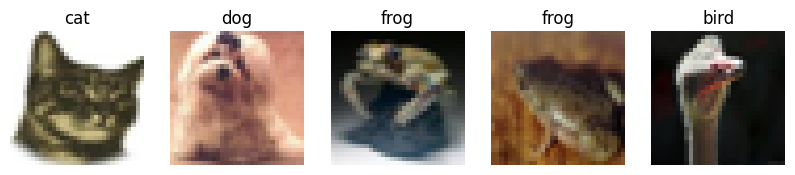

In [9]:
# Display 5 sample images with labels
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()

In [10]:
# Task 2: Build and Train a CNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [11]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


C:\Users\lenovo\anaconda3\envs\tf_cnn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


In [13]:
# Model summary
model.summary()

# Train the model
history = model.fit(x_train, y_train, epochs=15, batch_size=64,
                    validation_split=0.2, verbose=1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.2755 - loss: 1.9479 - val_accuracy: 0.4737 - val_loss: 1.4273
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4715 - loss: 1.4622 - val_accuracy: 0.5573 - val_loss: 1.2569
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5237 - loss: 1.3341 - val_accuracy: 0.5980 - val_loss: 1.1394
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.5557 - loss: 1.2566 - val_accuracy: 0.6121 - val_loss: 1.0955
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 18s 30ms/step - accuracy: 0.5763 - loss: 1.1924 - val_accuracy: 0.6236 - val_loss: 1.0577
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.5923 - loss: 1.1553 - val_accuracy: 0.6363 - val_loss: 1.0448
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.6129 - loss: 1.1078 - val_accuracy: 0.6597 - val_loss: 0.9861
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6252 - loss: 1.0675 - 

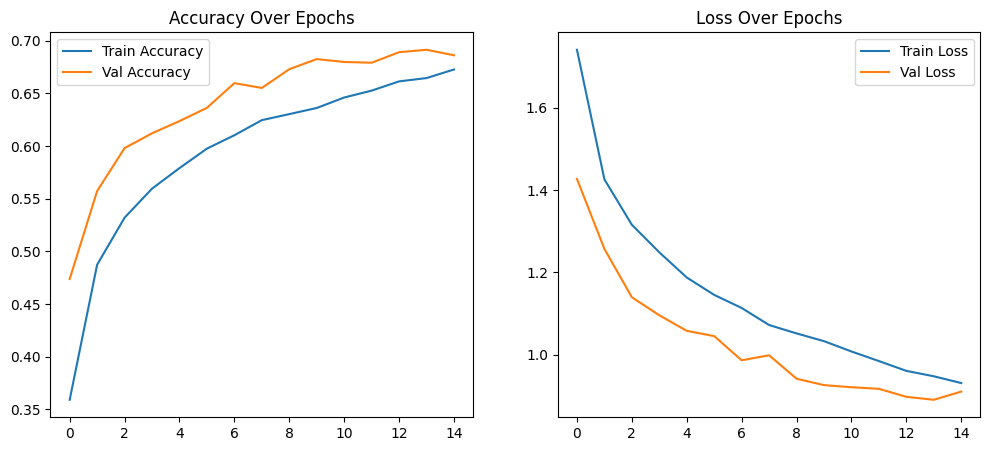

In [14]:
# Plot training/validation accuracy and loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy Over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Over Epochs')

plt.show()

# Explanation:
# If validation loss increases while training loss decreases, the model may be overfitting.


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6847 - loss: 0.9035
Test Accuracy: 0.6858
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.68      0.74      1181
           1       0.83      0.77      0.80      1188
           2       0.56      0.63      0.59      1232
           3       0.59      0.33      0.42      1274
           4       0.62      0.67      0.65      1179
           5       0.52      0.67      0.58      1230
           6       0.64      0.87      0.73      1123
           7       0.78      0.72      0.75      1217
           8       0.83      0.79      0.81      1189
           9       0.79      0.78      0.78      1187

    accuracy                           0.69     12000
   macro avg       0.70      0.69      0.69     12000
weighted avg       0.70      0.69      0.68     12000



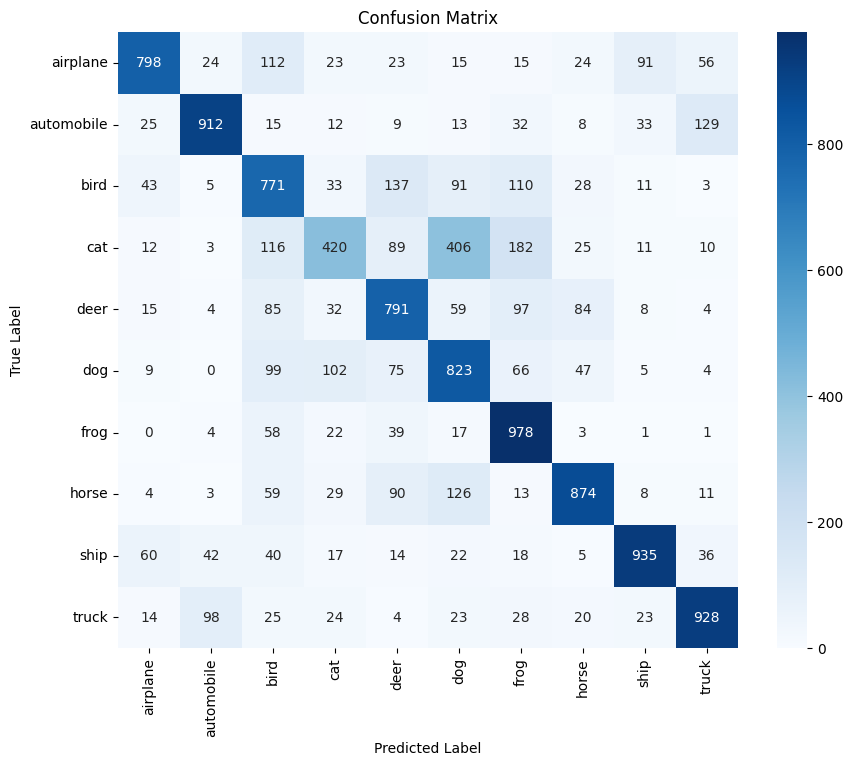

In [15]:
# Task 3: Evaluate the Model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluate on test data
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Classification report
print("Classification Report:\n", classification_report(y_true_labels, y_pred_labels))

# Confusion matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

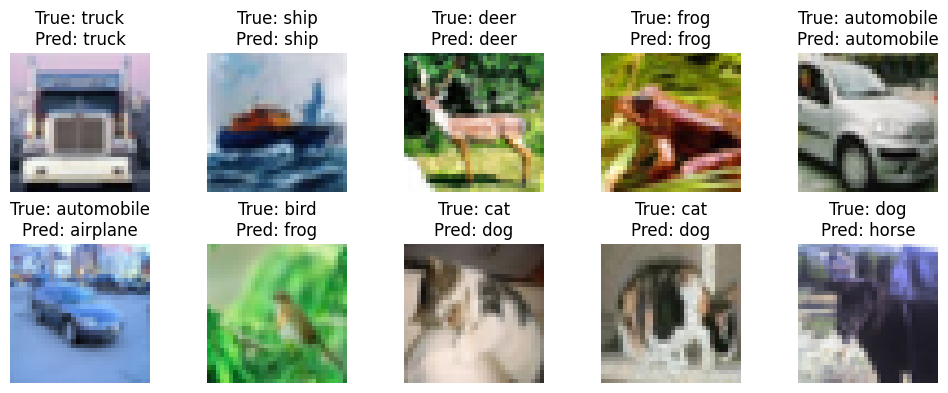

In [16]:
# Display some correct and incorrect predictions
correct = np.where(y_pred_labels == y_true_labels)[0]
incorrect = np.where(y_pred_labels != y_true_labels)[0]

plt.figure(figsize=(10, 4))
for i, idx in enumerate(correct[:5]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]}")
    plt.axis('off')

for i, idx in enumerate(incorrect[:5]):
    plt.subplot(2, 5, i+6)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [17]:
# Task 4: Experimentation with Optimizers

from tensorflow.keras.optimizers import SGD, RMSprop

# Try RMSProp optimizer
model_rms = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_rms.compile(optimizer=RMSprop(), loss='categorical_crossentropy', metrics=['accuracy'])
history_rms = model_rms.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2, verbose=1)

# Compare performance
print("\nPerformance Comparison Table:")
print(f"{'Model':<15} {'Final Val Accuracy':<20}")
print(f"{'Original (Adam)':<15} {history.history['val_accuracy'][-1]:<20.4f}")
print(f"{'RMSProp':<15} {history_rms.history['val_accuracy'][-1]:<20.4f}")


C:\Users\lenovo\anaconda3\envs\tf_cnn\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.2639 - loss: 1.9825 - val_accuracy: 0.4792 - val_loss: 1.4478
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.4657 - loss: 1.4894 - val_accuracy: 0.5474 - val_loss: 1.2729
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.5194 - loss: 1.3416 - val_accuracy: 0.5784 - val_loss: 1.2032
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5669 - loss: 1.2340 - val_accuracy: 0.6274 - val_loss: 1.0713
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.5859 - loss: 1.1751 - val_accuracy: 0.6274 - val_loss: 1.0669
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.6139 - loss: 1.1028 - val_accuracy: 0.6370 - val_loss: 1.0652
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.6232 - loss: 1.0925 - val_accuracy: 0.6473 - val_loss: 1.0142
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.6319 - loss: 1.0592 - 